# Clase 6 — Agente Farmacologico con MCP

## Parte 2: Model Context Protocol (MCP)

---

### De Parte 1 a Parte 2

| | Parte 1: Function Calling directo | Parte 2: MCP |
|---|---|---|
| **Donde viven las tools** | Hardcodeadas dentro del agente | Registradas en un servidor MCP |
| **Como las descubre el LLM** | Se le pasan al crear el modelo | El agente las descubre en runtime via el servidor |
| **Ventaja** | Simple, todo en un lugar | Desacoplado: podes cambiar tools sin tocar el agente |
| **Desventaja** | Acoplado: cambiar tools = cambiar el agente | Un poco mas de setup |

### Que es MCP?

**Model Context Protocol** es un protocolo estandar para separar las tools del agente.
En vez de que el agente tenga las tools adentro, las tools se registran en un **servidor MCP**
y el agente las **descubre en runtime** preguntandole al servidor que tools tiene disponibles.

En produccion, el servidor MCP corre como un proceso separado (via JSON-RPC/stdio).
En este notebook lo implementamos como clases Python in-process para simplificar.

## Setup

Ejecuta estas celdas para instalar las dependencias necesarias.

In [2]:
%pip install -q requests google-generativeai

Note: you may need to restart the kernel to use updated packages.


In [3]:
import json
import re
import unicodedata
import numpy as np
import google.generativeai as genai
import matplotlib.pyplot as plt
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

print("Setup completo!")

c:\Users\Usuario\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\Usuario\AppData\Local\Temp\ipykernel_14412\2450733061.py:5: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  import google.generativeai as genai


Setup completo!


In [ ]:
# Configura tu API key de Gemini
# Podes obtener una gratis en: https://aistudio.google.com/apikey
GEMINI_API_KEY = ""

genai.configure(api_key=GEMINI_API_KEY)

---

## Base de datos farmacologica

El agente trabaja sobre una base de datos de medicamentos para NSCLC (cancer de pulmon de celulas no pequenas).
Incluye 10 medicamentos con informacion detallada: mecanismo de accion, indicaciones, dosis, efectos secundarios,
contraindicaciones, costo y nivel de evidencia.

Tambien tiene una tabla de **interacciones** entre medicamentos con niveles de severidad.

**No modifiques estas celdas.**

In [5]:
# ══════════════════════════════════════════════════════════════════════
# BASE DE DATOS FARMACOLOGICA — NO MODIFICAR
# ══════════════════════════════════════════════════════════════════════

PHARMA_DB = [
    {
        "name": "Osimertinib",
        "brand": "Tagrisso",
        "drug_class": "EGFR-TKI (3ra generacion)",
        "mechanism": "Inhibidor irreversible de EGFR mutado (L858R, del19, T790M). Se une covalentemente al residuo C797 del dominio kinasa.",
        "targets": ["EGFR-L858R", "EGFR-del19", "EGFR-T790M"],
        "indications": "NSCLC metastasico EGFR+ (1ra linea); NSCLC con T790M post-progresion a TKI previo (2da linea); adyuvante post-cirugia en NSCLC EGFR+ estadios IB-IIIA.",
        "dosage": "80 mg oral/dia (reducir a 40 mg si toxicidad grado 3+)",
        "contraindications": ["Hipersensibilidad al osimertinib", "Embarazo/lactancia", "Enfermedad pulmonar intersticial activa"],
        "side_effects": ["Diarrea (42%)", "Rash (34%)", "Piel seca (23%)", "Paroniquia (22%)", "Estomatitis (15%)", "Prolongacion QTc (3-5%)"],
        "cost_monthly_usd": 14000,
        "evidence": "Nivel 1A — estudios FLAURA (1ra linea), ADAURA (adyuvante), AURA3 (T790M)",
        "approval_year": 2017
    },
    {
        "name": "Erlotinib",
        "brand": "Tarceva",
        "drug_class": "EGFR-TKI (1ra generacion)",
        "mechanism": "Inhibidor reversible competitivo del dominio tirosina-kinasa de EGFR. Bloquea la señalizacion de proliferacion celular.",
        "targets": ["EGFR-L858R", "EGFR-del19"],
        "indications": "NSCLC metastasico EGFR+ (ya no es 1ra linea preferida). Combinacion con ramucirumab o bevacizumab.",
        "dosage": "150 mg oral/dia en ayunas (1h antes o 2h despues de comida)",
        "contraindications": ["Hipersensibilidad", "Embarazo/lactancia", "Insuficiencia hepatica severa"],
        "side_effects": ["Rash acneiforme (75%)", "Diarrea (54%)", "Anorexia (30%)", "Fatiga (25%)", "Nauseas (20%)", "Hepatotoxicidad (2-5%)"],
        "cost_monthly_usd": 7500,
        "evidence": "Nivel 1A — estudio EURTAC, ENSURE",
        "approval_year": 2004
    },
    {
        "name": "Gefitinib",
        "brand": "Iressa",
        "drug_class": "EGFR-TKI (1ra generacion)",
        "mechanism": "Inhibidor reversible selectivo del dominio tirosina-kinasa de EGFR. Similar a erlotinib pero con perfil de selectividad ligeramente diferente.",
        "targets": ["EGFR-L858R", "EGFR-del19"],
        "indications": "NSCLC metastasico EGFR+ (alternativa a erlotinib en 1ra generacion).",
        "dosage": "250 mg oral/dia (con o sin alimentos)",
        "contraindications": ["Hipersensibilidad", "Embarazo/lactancia", "Enfermedad pulmonar intersticial"],
        "side_effects": ["Diarrea (47%)", "Rash (44%)", "Piel seca (28%)", "Nauseas (18%)", "Elevacion transaminasas (10%)", "Enfermedad pulmonar intersticial (1-2%)"],
        "cost_monthly_usd": 6800,
        "evidence": "Nivel 1A — estudio IPASS, NEJ002",
        "approval_year": 2003
    },
    {
        "name": "Afatinib",
        "brand": "Gilotrif",
        "drug_class": "EGFR-TKI (2da generacion)",
        "mechanism": "Inhibidor irreversible pan-HER (EGFR/HER1, HER2, HER4). Bloquea toda la familia ErbB, no solo EGFR.",
        "targets": ["EGFR-L858R", "EGFR-del19", "HER2"],
        "indications": "NSCLC metastasico EGFR+ (alternativa, especialmente en del19). Tambien aprobado para carcinoma escamoso de pulmon post-platino.",
        "dosage": "40 mg oral/dia en ayunas (reducir a 30 mg o 20 mg si toxicidad)",
        "contraindications": ["Hipersensibilidad", "Embarazo/lactancia", "Deterioro renal severo (ClCr <15 ml/min)"],
        "side_effects": ["Diarrea (96%)", "Rash (89%)", "Estomatitis (72%)", "Paroniquia (58%)", "Piel seca (31%)", "Disminucion del apetito (29%)"],
        "cost_monthly_usd": 8200,
        "evidence": "Nivel 1A — estudios LUX-Lung 3, LUX-Lung 6, LUX-Lung 7",
        "approval_year": 2013
    },
    {
        "name": "Pembrolizumab",
        "brand": "Keytruda",
        "drug_class": "Inmunoterapia anti-PD-1",
        "mechanism": "Anticuerpo monoclonal humanizado anti-PD-1. Bloquea el receptor PD-1 en linfocitos T, restaurando la respuesta inmune antitumoral.",
        "targets": ["PD-1"],
        "indications": "NSCLC metastasico PD-L1+ (>=1%) sin mutaciones driver (EGFR/ALK). Monoterapia si PD-L1>=50%; combinacion con quimio si PD-L1 1-49%.",
        "dosage": "200 mg IV cada 3 semanas (o 400 mg IV cada 6 semanas)",
        "contraindications": ["Hipersensibilidad", "Embarazo/lactancia", "Enfermedad autoinmune activa severa", "Uso de inmunosupresores cronicos"],
        "side_effects": ["Fatiga (25%)", "Prurito (18%)", "Rash (15%)", "Diarrea (12%)", "Neumonitis inmunomediada (3-5%)", "Hepatitis inmunomediada (1-3%)", "Tiroiditis (8%)"],
        "cost_monthly_usd": 18000,
        "evidence": "Nivel 1A — estudios KEYNOTE-024 (monoterapia), KEYNOTE-189 (combo con quimio)",
        "approval_year": 2016
    },
    {
        "name": "Docetaxel",
        "brand": "Taxotere",
        "drug_class": "Quimioterapia (taxano)",
        "mechanism": "Estabiliza microtubulos impidiendo su despolimerizacion. Bloquea la mitosis celular en fase M del ciclo celular.",
        "targets": ["Microtubulos"],
        "indications": "NSCLC metastasico como 2da linea post-platino. Tambien en combinacion con cisplatino como 1ra linea.",
        "dosage": "75 mg/m2 IV cada 3 semanas (premedicacion con dexametasona obligatoria)",
        "contraindications": ["Neutrofilos <1500/mm3", "Hipersensibilidad a polisorbato 80", "Embarazo/lactancia", "Insuficiencia hepatica severa"],
        "side_effects": ["Neutropenia (75%)", "Alopecia (65%)", "Fatiga (53%)", "Nauseas (34%)", "Diarrea (25%)", "Neuropatia periferica (20%)", "Retencion de liquidos (15%)"],
        "cost_monthly_usd": 3500,
        "evidence": "Nivel 1A — estudio TAX 317, TAX 320",
        "approval_year": 1999
    },
    {
        "name": "Carboplatin",
        "brand": "Paraplatin",
        "drug_class": "Quimioterapia (platino)",
        "mechanism": "Forma aductos con el ADN generando enlaces cruzados inter e intracatenarios. Inhibe replicacion y transcripcion del ADN tumoral.",
        "targets": ["ADN"],
        "indications": "NSCLC metastasico en combinacion (carbo + pemetrexed, carbo + paclitaxel). Base de muchos esquemas de 1ra linea sin mutacion driver.",
        "dosage": "AUC 5-6 IV cada 3 semanas (calcular dosis por formula de Calvert)",
        "contraindications": ["Hipersensibilidad a compuestos de platino", "Mielosupresion severa", "Embarazo/lactancia", "Insuficiencia renal severa (ClCr <15 ml/min)"],
        "side_effects": ["Trombocitopenia (62%)", "Neutropenia (55%)", "Anemia (48%)", "Nauseas/vomitos (45%)", "Fatiga (35%)", "Nefrotoxicidad (10%)", "Ototoxicidad (5%)"],
        "cost_monthly_usd": 800,
        "evidence": "Nivel 1A — multiples estudios fase III como base de combinaciones",
        "approval_year": 1989
    },
    {
        "name": "Pemetrexed",
        "brand": "Alimta",
        "drug_class": "Quimioterapia (antifolato)",
        "mechanism": "Antifolato multitarget que inhibe timidilato sintasa (TS), dihidrofolato reductasa (DHFR) y glicinamida ribonucleotido formiltransferasa (GARFT).",
        "targets": ["TS", "DHFR", "GARFT"],
        "indications": "NSCLC no escamoso metastasico en combinacion con platino (1ra linea) y como mantenimiento. NO indicado en histologia escamosa.",
        "dosage": "500 mg/m2 IV cada 3 semanas (suplementar con acido folico y vitamina B12 obligatorio)",
        "contraindications": ["Hipersensibilidad", "Embarazo/lactancia", "ClCr <45 ml/min", "Histologia escamosa de NSCLC"],
        "side_effects": ["Neutropenia (40%)", "Fatiga (35%)", "Nauseas (30%)", "Anemia (20%)", "Estomatitis (15%)", "Rash (10%)", "Elevacion de creatinina (8%)"],
        "cost_monthly_usd": 6000,
        "evidence": "Nivel 1A — estudio PARAMOUNT (mantenimiento), JMDB (1ra linea con cisplatino)",
        "approval_year": 2004
    },
    {
        "name": "Bevacizumab",
        "brand": "Avastin",
        "drug_class": "Antiangiogenico (anti-VEGF)",
        "mechanism": "Anticuerpo monoclonal anti-VEGF-A. Inhibe la angiogenesis tumoral impidiendo la union de VEGF a sus receptores.",
        "targets": ["VEGF-A"],
        "indications": "NSCLC no escamoso metastasico en combinacion con quimioterapia (carbo + paclitaxel + bev). NO usar en histologia escamosa (riesgo hemoptisis).",
        "dosage": "15 mg/kg IV cada 3 semanas (o 7.5 mg/kg cada 3 semanas en algunos esquemas)",
        "contraindications": ["Histologia escamosa", "Hemoptisis reciente", "Cirugia mayor reciente (<28 dias)", "Hipertension no controlada", "Embarazo/lactancia"],
        "side_effects": ["Hipertension (25%)", "Proteinuria (20%)", "Epistaxis (15%)", "Fatiga (12%)", "Hemorragia (8%)", "Perforacion GI (1-2%)", "Tromboembolismo arterial (3%)"],
        "cost_monthly_usd": 9500,
        "evidence": "Nivel 1A — estudio ECOG 4599, AVAiL",
        "approval_year": 2006
    },
    {
        "name": "Crizotinib",
        "brand": "Xalkori",
        "drug_class": "Inhibidor ALK/ROS1",
        "mechanism": "Inhibidor de tirosina kinasa de ALK, ROS1 y MET. Bloquea la señalizacion oncogenica en tumores con reordenamientos ALK o ROS1.",
        "targets": ["ALK", "ROS1", "MET"],
        "indications": "NSCLC metastasico ALK+ (ya no es 1ra linea preferida, reemplazado por alectinib). NSCLC ROS1+.",
        "dosage": "250 mg oral cada 12 horas (con o sin alimentos)",
        "contraindications": ["Hipersensibilidad", "Embarazo/lactancia", "Prolongacion QTc congenita", "Insuficiencia hepatica severa"],
        "side_effects": ["Trastornos visuales (62%)", "Nauseas (55%)", "Diarrea (43%)", "Vomitos (40%)", "Edema (30%)", "Elevacion transaminasas (15%)", "Bradicardia (5%)"],
        "cost_monthly_usd": 16000,
        "evidence": "Nivel 1A — estudio PROFILE 1014 (ALK), PROFILE 1001 (ROS1)",
        "approval_year": 2011
    }
]

INTERACTIONS_DB = [
    {"drug_a": "Osimertinib", "drug_b": "Erlotinib", "severity": "CONTRAINDICADO", "detail": "Mismo target EGFR — toxicidad aditiva sin beneficio clinico. No combinar TKIs del mismo target."},
    {"drug_a": "Osimertinib", "drug_b": "Gefitinib", "severity": "CONTRAINDICADO", "detail": "Mismo target EGFR — toxicidad aditiva sin beneficio clinico."},
    {"drug_a": "Osimertinib", "drug_b": "Afatinib", "severity": "CONTRAINDICADO", "detail": "Ambos inhiben EGFR — riesgo de toxicidad severa (rash, diarrea, prolongacion QTc)."},
    {"drug_a": "Erlotinib", "drug_b": "Gefitinib", "severity": "CONTRAINDICADO", "detail": "Ambos son EGFR-TKI 1ra generacion — mecanismo identico, sin beneficio en combinacion."},
    {"drug_a": "Osimertinib", "drug_b": "Warfarina", "severity": "PRECAUCION", "detail": "Osimertinib es sustrato e inhibidor de CYP3A4. Monitorear INR frecuentemente — riesgo de sangrado aumentado."},
    {"drug_a": "Erlotinib", "drug_b": "Warfarina", "severity": "PRECAUCION", "detail": "Erlotinib inhibe CYP1A2 y CYP3A4. Monitorear INR — reportes de sangrado con uso concomitante."},
    {"drug_a": "Pembrolizumab", "drug_b": "Corticoides", "severity": "PRECAUCION", "detail": "Dosis altas de corticoides (>10 mg prednisona/dia) pueden reducir eficacia de inmunoterapia al suprimir linfocitos T."},
    {"drug_a": "Pembrolizumab", "drug_b": "Osimertinib", "severity": "PRECAUCION", "detail": "Combinacion asociada a mayor incidencia de neumonitis inmunomediada. No recomendada de rutina."},
    {"drug_a": "Carboplatin", "drug_b": "Pemetrexed", "severity": "COMPATIBLE", "detail": "Combinacion estandar de 1ra linea para NSCLC no escamoso. Esquema validado en multiples estudios fase III."},
    {"drug_a": "Carboplatin", "drug_b": "Docetaxel", "severity": "COMPATIBLE", "detail": "Combinacion usada en 1ra linea. Monitorear mielosupresion aditiva (neutropenia)."},
    {"drug_a": "Carboplatin", "drug_b": "Bevacizumab", "severity": "COMPATIBLE", "detail": "Combinacion estandar (carbo + paclitaxel + bev). Solo en histologia no escamosa."},
    {"drug_a": "Carboplatin", "drug_b": "Pembrolizumab", "severity": "COMPATIBLE", "detail": "Combinacion aprobada: carbo + pemetrexed + pembrolizumab (KEYNOTE-189). Esquema estandar para NSCLC no escamoso sin driver."},
    {"drug_a": "Docetaxel", "drug_b": "Bevacizumab", "severity": "PRECAUCION", "detail": "Combinacion posible pero monitorear neutropenia severa y riesgo de sangrado."},
    {"drug_a": "Pemetrexed", "drug_b": "AINEs", "severity": "PRECAUCION", "detail": "AINEs reducen eliminacion renal de pemetrexed. Suspender AINEs 2-5 dias antes de cada ciclo."},
    {"drug_a": "Bevacizumab", "drug_b": "Anticoagulantes", "severity": "PRECAUCION", "detail": "Riesgo aumentado de hemorragia. Monitorear signos de sangrado y ajustar dosis de anticoagulante."},
    {"drug_a": "Crizotinib", "drug_b": "Osimertinib", "severity": "PRECAUCION", "detail": "Ambos prolongan QTc. Si se combinan, monitorear ECG. Targets diferentes (ALK vs EGFR) pero toxicidad cardiaca aditiva."},
    {"drug_a": "Gefitinib", "drug_b": "Omeprazol", "severity": "PRECAUCION", "detail": "IBP reducen absorcion de gefitinib (requiere pH acido). Evitar IBP o usar anti-H2 con separacion de 12h."},
    {"drug_a": "Afatinib", "drug_b": "P-gp inductores", "severity": "PRECAUCION", "detail": "Rifampicina y otros inductores de P-gp reducen niveles de afatinib. Ajustar dosis si uso concomitante necesario."}
]

print(f"Base de datos cargada: {len(PHARMA_DB)} medicamentos, {len(INTERACTIONS_DB)} interacciones")

Base de datos cargada: 10 medicamentos, 18 interacciones


---

## Las tools disponibles (ya implementadas)

Tu agente tiene acceso a 4 tools ya programadas. **No necesitas modificar este codigo.**
Leelo para entender que hace cada una — lo vas a necesitar para registrarlas en el servidor MCP.

| Tool | Que hace | Parametros |
|---|---|---|
| `search_drug` | Busca un medicamento por nombre generico o comercial | `drug_name` (str) |
| `check_interaction` | Verifica interacciones entre dos medicamentos | `drug_a` (str), `drug_b` (str) |
| `list_drugs_by_class` | Lista medicamentos de una clase terapeutica | `drug_class` (str) |
| `get_treatment_options` | Dado un target molecular, retorna medicamentos que lo atacan | `target` (str) |

In [6]:
# ══════════════════════════════════════════════════════════════════════
# TOOLS YA IMPLEMENTADAS — NO MODIFICAR
# ══════════════════════════════════════════════════════════════════════

def search_drug(drug_name: str) -> dict:
    """Busca un medicamento por nombre generico o comercial."""
    name_lower = drug_name.lower().strip()
    for drug in PHARMA_DB:
        if name_lower in drug["name"].lower() or name_lower in drug["brand"].lower():
            return {"found": True, "drug": drug}
    return {"found": False, "message": f"Medicamento '{drug_name}' no encontrado en la base de datos."}


def check_interaction(drug_a: str, drug_b: str) -> dict:
    """Verifica interacciones entre dos medicamentos."""
    a_lower = drug_a.lower().strip()
    b_lower = drug_b.lower().strip()
    for interaction in INTERACTIONS_DB:
        ia = interaction["drug_a"].lower()
        ib = interaction["drug_b"].lower()
        if (a_lower in ia or a_lower in ib) and (b_lower in ia or b_lower in ib):
            return {"found": True, "interaction": interaction}
    return {
        "found": False,
        "message": f"No se encontro interaccion registrada entre '{drug_a}' y '{drug_b}'. Consultar ficha tecnica."
    }


def list_drugs_by_class(drug_class: str) -> dict:
    """Lista medicamentos de una clase terapeutica."""
    class_lower = drug_class.lower().strip()
    results = []
    for drug in PHARMA_DB:
        if class_lower in drug["drug_class"].lower():
            results.append({
                "name": drug["name"],
                "brand": drug["brand"],
                "drug_class": drug["drug_class"],
                "cost_monthly_usd": drug["cost_monthly_usd"]
            })
    if results:
        return {"found": True, "count": len(results), "drugs": results}
    return {"found": False, "message": f"No se encontraron medicamentos de la clase '{drug_class}'."}


def get_treatment_options(target: str) -> dict:
    """Retorna medicamentos que atacan un target molecular especifico."""
    target_lower = target.lower().strip()
    results = []
    for drug in PHARMA_DB:
        for t in drug["targets"]:
            if target_lower in t.lower():
                results.append({
                    "name": drug["name"],
                    "brand": drug["brand"],
                    "drug_class": drug["drug_class"],
                    "indications": drug["indications"],
                    "evidence": drug["evidence"]
                })
                break
    if results:
        return {"found": True, "target": target, "count": len(results), "drugs": results}
    return {"found": False, "message": f"No se encontraron medicamentos para el target '{target}'."}


# Test rapido
print("Test search_drug:")
print(search_drug("tagrisso"))
print("\nTest check_interaction:")
print(check_interaction("osimertinib", "erlotinib"))
print("\nTest list_drugs_by_class:")
print(list_drugs_by_class("EGFR"))
print("\nTest get_treatment_options:")
print(get_treatment_options("ALK"))

Test search_drug:
{'found': True, 'drug': {'name': 'Osimertinib', 'brand': 'Tagrisso', 'drug_class': 'EGFR-TKI (3ra generacion)', 'mechanism': 'Inhibidor irreversible de EGFR mutado (L858R, del19, T790M). Se une covalentemente al residuo C797 del dominio kinasa.', 'targets': ['EGFR-L858R', 'EGFR-del19', 'EGFR-T790M'], 'indications': 'NSCLC metastasico EGFR+ (1ra linea); NSCLC con T790M post-progresion a TKI previo (2da linea); adyuvante post-cirugia en NSCLC EGFR+ estadios IB-IIIA.', 'dosage': '80 mg oral/dia (reducir a 40 mg si toxicidad grado 3+)', 'contraindications': ['Hipersensibilidad al osimertinib', 'Embarazo/lactancia', 'Enfermedad pulmonar intersticial activa'], 'side_effects': ['Diarrea (42%)', 'Rash (34%)', 'Piel seca (23%)', 'Paroniquia (22%)', 'Estomatitis (15%)', 'Prolongacion QTc (3-5%)'], 'cost_monthly_usd': 14000, 'evidence': 'Nivel 1A — estudios FLAURA (1ra linea), ADAURA (adyuvante), AURA3 (T790M)', 'approval_year': 2017}}

Test check_interaction:
{'found': True, 'i

---

## El servidor MCP

En produccion, un servidor MCP corre como proceso separado y se comunica via JSON-RPC.
Aca lo implementamos como una clase Python que replica los dos endpoints principales:

- **`tools/list`** → devuelve las tools disponibles con su metadata (nombre, descripcion, parametros)
- **`tools/call`** → ejecuta una tool especifica con los argumentos dados

El servidor NO sabe nada del LLM — solo registra tools y las ejecuta cuando se lo piden.

**No modifiques esta celda.**

In [9]:
# ══════════════════════════════════════════════════════════════════════
# SERVIDOR MCP — NO MODIFICAR
# ══════════════════════════════════════════════════════════════════════

class MCPServer:
    """
    Servidor MCP simplificado (in-process).
    En produccion correria como proceso separado via JSON-RPC/stdio.
    """

    def __init__(self, name: str):
        self.name = name
        self.tools = {}  # name -> {description, parameters, handler}

    def register_tool(self, name: str, description: str, parameters: dict, handler):
        """Registra una tool en el servidor."""
        self.tools[name] = {
            "name": name,
            "description": description,
            "parameters": parameters,
            "handler": handler,
        }

    def handle_list_tools(self) -> list:
        """Endpoint tools/list — retorna metadata de todas las tools (sin handlers)."""
        return [
            {k: v for k, v in tool.items() if k != "handler"}
            for tool in self.tools.values()
        ]

    def handle_call_tool(self, tool_name: str, arguments: dict) -> str:
        """Endpoint tools/call — ejecuta una tool y retorna el resultado como string JSON."""
        if tool_name not in self.tools:
            return json.dumps({"error": f"Tool '{tool_name}' no encontrada en el servidor '{self.name}'."})
        handler = self.tools[tool_name]["handler"]
        try:
            result = handler(**arguments)
            return json.dumps(result, ensure_ascii=False)
        except Exception as e:
            return json.dumps({"error": str(e)})

    def __repr__(self):
        return f"MCPServer(name='{self.name}', tools={list(self.tools.keys())})"


print("Clase MCPServer definida correctamente.")

Clase MCPServer definida correctamente.


---

## Ejercicio 1: Registrar tools en el servidor MCP

Ahora tenes que crear un servidor MCP y **registrar las 4 tools** en el.
Para cada tool, necesitas escribir una **descripcion** que le diga al LLM:
- **Que hace** la tool
- **Cuando** deberia usarla (y cuando NO)
- **Que datos** devuelve

Los handlers ya estan conectados — solo necesitas escribir las descripciones.

> Pensa en las descripciones como un "prompt" para el LLM sobre cada tool.
> Si la descripcion es vaga, el agente va a elegir mal.

In [57]:
# ── TODO: Crear servidor MCP y registrar las 4 tools ────────────────

pharma_server = MCPServer("pharma-nsclc")

# Tool 1: search_drug
pharma_server.register_tool(
    name="search_drug",
    description=(
        "Busca un medicamento en la base de datos a partir de su nombre generico o comercial (marca). "
        "Usar esta herramienta cuando el usuario menciona un farmaco especifico y se necesita obtener informacion general sobre el mismo. "
        "No usar si se busca comparar multiples medicamentos, listar por clase o analizar interacciones. "
        "Devuelve un objeto indicando si el medicamento fue encontrado y, en caso afirmativo, un diccionario con toda su informacion (nombre, marca, clase, indicaciones, targets, evidencia, costo, etc.)."
    ),
    parameters={
        "type": "object",
        "properties": {
            "drug_name": {
                "type": "string",
                "description": "Nombre generico o comercial del medicamento a buscar",
            }
        },
        "required": ["drug_name"],
    },
    handler=search_drug,
)

# Tool 2: check_interaction
pharma_server.register_tool(
    name="check_interaction",
    description=(
        "Verifica si existe una interaccion conocida entre dos medicamentos en la base de datos. "
        "Usar esta herramienta cuando el usuario pregunta por combinaciones de farmacos o posibles riesgos al administrarlos juntos. "
        "No usar para buscar informacion individual de un farmaco o listar tratamientos. "
        "Devuelve un objeto indicando si se encontro una interaccion y, en caso positivo, detalles de la misma (descripcion, severidad, recomendaciones). "
        "Si no se encuentra, devuelve un mensaje indicando que no hay interaccion registrada"
    ),
    parameters={
        "type": "object",
        "properties": {
            "drug_a": {
                "type": "string",
                "description": "Nombre del primer medicamento",
            },
            "drug_b": {
                "type": "string",
                "description": "Nombre del segundo medicamento",
            },
        },
        "required": ["drug_a", "drug_b"],
    },
    handler=check_interaction,
)

# Tool 3: list_drugs_by_class
pharma_server.register_tool(
    name="list_drugs_by_class",
    description=(
    "Lista todos los medicamentos pertenecientes a una clase terapeutica especifica "
    "(por ejemplo: EGFR, inmunoterapia, platino, etc.). "
    "Usar esta tool cuando el usuario quiera explorar opciones dentro de una misma clase "
    "o comparar farmacos similares. "
    "IMPORTANTE: el parametro 'drug_class' debe ser un termino clave presente en la base de datos "
    "(por ejemplo: 'EGFR', no 'inhibidores de EGFR'). "
    "No usar para buscar informacion de un farmaco puntual ni para targets moleculares especificos. "
    "Devuelve un objeto con la cantidad de medicamentos encontrados y una lista con informacion resumida de cada uno (nombre, marca, clase y costo mensual)."
    ),
    parameters={
        "type": "object",
        "properties": {
            "drug_class": {
                "type": "string",
                "description": "Clase terapeutica a buscar",
            }
        },
        "required": ["drug_class"],
    },
    handler=list_drugs_by_class,
)

# Tool 4: get_treatment_options
pharma_server.register_tool(
    name="get_treatment_options",
    description=(
        "Obtiene medicamentos que actuan sobre un target molecular especifico (por ejemplo EGFR, ALK o PD-1). "
        "Usar esta herramienta cuando el usuario pregunta por tratamientos dirigidos segun biomarcadores o mutaciones. "
        "No usar para busquedas por nombre de farmaco ni para clases generales. "
        "Devuelve un objeto con la cantidad de opciones encontradas y una lista de medicamentos con informacion relevante (nombre, marca, clase, indicaciones clinicas y nivel de evidencia)."
    ),
    parameters={
        "type": "object",
        "properties": {
            "target": {
                "type": "string",
                "description": "Target molecular a buscar (ej: EGFR-L858R, ALK, PD-1)",
            }
        },
        "required": ["target"],
    },
    handler=get_treatment_options,
)

# Verificar
print(f"\n{pharma_server}")
tools_list = pharma_server.handle_list_tools()
print(f"\nTools descubiertas via MCP ({len(tools_list)}):")
for t in tools_list:
    desc_preview = t['description'][:60] + '...' if len(t['description']) > 60 else t['description']
    has_desc = "OK" if t['description'].strip() else "FALTA DESCRIPCION"
    print(f"  [{has_desc}] {t['name']}: {desc_preview}")


MCPServer(name='pharma-nsclc', tools=['search_drug', 'check_interaction', 'list_drugs_by_class', 'get_treatment_options'])

Tools descubiertas via MCP (4):
  [OK] search_drug: Busca un medicamento en la base de datos a partir de su nomb...
  [OK] check_interaction: Verifica si existe una interaccion conocida entre dos medica...
  [OK] list_drugs_by_class: Lista todos los medicamentos pertenecientes a una clase tera...
  [OK] get_treatment_options: Obtiene medicamentos que actuan sobre un target molecular es...


---

## Ejercicio 2: Escribir el system prompt del agente

El system prompt define el comportamiento general del agente: como debe responder,
que debe hacer y que NO debe hacer.

Pensalo como las "instrucciones de trabajo" que le das a un empleado nuevo.
Un buen system prompt para un agente farmacologico deberia incluir:
- **Rol**: que es el agente y sobre que dominio trabaja
- **Regla de oro**: SIEMPRE usar las tools para obtener datos, NUNCA inventar
- **Formato**: como debe responder (conciso, con datos exactos, etc.)
- **Seguridad**: recordar que la informacion es de referencia, no reemplaza al medico

**Escribe tu system prompt en la celda de abajo.**

In [7]:
SYSTEM_PROMPT = """
Eres un asistente farmacologico especializado en oncologia (NSCLC) que trabaja con una base de datos estructurada de medicamentos.

ROL:
Tu funcion es ayudar a responder consultas sobre farmacos, interacciones, clases terapeuticas y tratamientos dirigidos a targets moleculares, utilizando exclusivamente las herramientas disponibles.

REGLA DE ORO:
- SIEMPRE debes usar las tools para obtener informacion.
- NUNCA inventes datos, medicamentos, interacciones o evidencia.
- Si la tool no devuelve resultados, debes informarlo claramente.

IDENTIFICACION DE INTENCION:
- Si la consulta menciona un medicamento especifico → usa 'search_drug'
- Si menciona combinaciones o interacciones → usa 'check_interaction'
- Si menciona clases (ej: "EGFR", "inhibidores") → usa 'list_drugs_by_class'
- Si menciona targets moleculares → usa 'get_treatment_options'

USO DE TOOLS:
- Antes de responder, analiza si la consulta puede resolverse con una tool.
- Si existe una tool aplicable, debes usarla obligatoriamente.
- No respondas sin usar tools si la informacion esta disponible en ellas.

FORMATO DE RESPUESTA:
- Responde de forma clara, concisa y estructurada.
- Usa bullet points cuando haya multiples resultados.
- No omitas informacion relevante.

REGLAS DE CONTENIDO:
- Debes listar TODOS los resultados devueltos por la tool.
- Para cada medicamento incluye:
  - Nombre generico
  - Nombre comercial (brand)
  - Clase terapeutica
- Incluye contexto clinico clave (ej: 1ra linea, 2da linea, no escamoso).
- No resumas informacion critica.

FORMATO DE NUMEROS:
- Escribe numeros sin separadores de miles (ej: 18000, no 18,000).

MANEJO DE ERRORES:
- Si no se encuentra informacion, indicalo explicitamente.
- No completes informacion faltante con suposiciones.

SEGURIDAD:
- La informacion es de referencia y no reemplaza al medico.
- No des recomendaciones personalizadas.

OBJETIVO:
Brindar informacion precisa, completa y estructurada basada exclusivamente en datos de las tools.
"""

---

## Ejercicio 3: Configurar y probar el agente

La clase `MCPAgent` ya esta implementada. Es igual al `ToolAgent` de la Parte 1 pero con una diferencia clave:
**descubre las tools del servidor MCP en runtime** en vez de recibirlas hardcodeadas.

El flujo:
1. El agente llama `server.handle_list_tools()` para descubrir que tools hay
2. Convierte esas tools al formato `function_declarations` de Gemini
3. El loop de function calling es el mismo, pero ejecuta con `server.handle_call_tool()`

**No modifiques la clase.** Solo ejecuta la celda para crearla, y luego proba el agente.

In [59]:
# ══════════════════════════════════════════════════════════════════════
# CLASE MCPAgent — NO MODIFICAR
# ══════════════════════════════════════════════════════════════════════

class MCPAgent:
    """
    Agente que descubre tools de un servidor MCP en runtime
    y las usa via function calling de Gemini.
    """

    def __init__(self, server: MCPServer, system_prompt: str, model_name: str = "gemini-2.5-flash"):
        self.server = server
        self.system_prompt = system_prompt
        self.model_name = model_name
        self.tool_declarations = self._discover_tools()
        self.model = genai.GenerativeModel(
            model_name=model_name,
            system_instruction=system_prompt,
            tools=self.tool_declarations,
        )
        self.tool_log = []
        print(f"MCPAgent inicializado con modelo '{model_name}' y {len(self.tool_declarations)} tools del servidor '{server.name}'.")

    def _discover_tools(self) -> list:
        """Descubre tools del servidor MCP y las convierte al formato de Gemini."""
        mcp_tools = self.server.handle_list_tools()
        gemini_tools = []
        for tool in mcp_tools:
            gemini_tools.append(
                genai.protos.Tool(
                    function_declarations=[
                        genai.protos.FunctionDeclaration(
                            name=tool["name"],
                            description=tool["description"],
                            parameters=genai.protos.Schema(
                                type=genai.protos.Type.OBJECT,
                                properties={
                                    k: genai.protos.Schema(type=genai.protos.Type.STRING, description=v.get("description", ""))
                                    for k, v in tool["parameters"]["properties"].items()
                                },
                                required=tool["parameters"].get("required", []),
                            ),
                        )
                    ]
                )
            )
        return gemini_tools

    def chat(self, user_message: str, verbose: bool = True) -> str:
        """Envia un mensaje al agente y retorna la respuesta final."""
        if verbose:
            print(f"\n{'='*60}")
            print(f"Usuario: {user_message}")
            print(f"{'='*60}")

        self.tool_log.append([])
        chat_session = self.model.start_chat()
        response = chat_session.send_message(user_message)

        max_iterations = 10
        for _ in range(max_iterations):
            has_function_call = False
            function_responses = []

            for part in response.candidates[0].content.parts:
                if hasattr(part, "function_call") and part.function_call.name:
                    has_function_call = True
                    fn_name = part.function_call.name
                    fn_args = dict(part.function_call.args)

                    if verbose:
                        print(f"\n[Tool call] {fn_name}({fn_args})")

                    # Ejecutar tool via servidor MCP (retorna string JSON)
                    result_str = self.server.handle_call_tool(fn_name, fn_args)

                    if verbose:
                        print(f"[Tool result] {result_str[:200]}{'...' if len(result_str) > 200 else ''}")

                    self.tool_log[-1].append({"tool": fn_name, "args": fn_args})

                    # Pasar el resultado parseado como dict al FunctionResponse
                    try:
                        result_dict = json.loads(result_str)
                    except (json.JSONDecodeError, TypeError):
                        result_dict = {"result": result_str}

                    function_responses.append(
                        genai.protos.Part(
                            function_response=genai.protos.FunctionResponse(
                                name=fn_name,
                                response=result_dict,
                            )
                        )
                    )

            if not has_function_call:
                break

            response = chat_session.send_message(function_responses)

        # Extraer texto de forma segura
        text_parts = [
            part.text for part in response.candidates[0].content.parts
            if hasattr(part, 'text') and part.text
        ]
        final_text = "\n".join(text_parts) if text_parts else "(Sin respuesta de texto)"

        if verbose:
            print(f"\nAgente: {final_text}")
        return final_text


print("Clase MCPAgent definida correctamente.")

Clase MCPAgent definida correctamente.


In [60]:
# Crear el agente conectado al servidor MCP
agent = MCPAgent(
    server=pharma_server,
    system_prompt=SYSTEM_PROMPT,
)

MCPAgent inicializado con modelo 'gemini-2.5-flash' y 4 tools del servidor 'pharma-nsclc'.


### Pruebas manuales

Usa `verbose=True` para ver que tools elige el agente. Proba con distintas preguntas
para verificar que tus descripciones y tu prompt funcionan bien **antes** de correr el benchmark.

In [61]:
# Proba tu agente con preguntas de ejemplo (modifica las preguntas libremente)
preguntas_test = [
    "Cual es el tratamiento de primera linea para NSCLC con mutacion EGFR-L858R?",
    "Se pueden combinar carboplatin y pemetrexed?",
    "Cuanto cuesta pembrolizumab por mes?",
]

for q in preguntas_test:
    print("=" * 60)
    print(f"Q: {q}")
    r = agent.chat(q, verbose=True)
    print(f"\nA: {r}\n")

Q: Cual es el tratamiento de primera linea para NSCLC con mutacion EGFR-L858R?

Usuario: Cual es el tratamiento de primera linea para NSCLC con mutacion EGFR-L858R?

[Tool call] get_treatment_options({'target': 'EGFR-L858R'})
[Tool result] {"found": true, "target": "EGFR-L858R", "count": 4, "drugs": [{"name": "Osimertinib", "brand": "Tagrisso", "drug_class": "EGFR-TKI (3ra generacion)", "indications": "NSCLC metastasico EGFR+ (1ra linea...

Agente: Para el NSCLC con mutación EGFR-L858R, las opciones de tratamiento son:

*   **Osimertinib** (nombre comercial: Tagrisso)
    *   Clase terapéutica: EGFR-TKI (3ra generación)
    *   Indicaciones: NSCLC metastásico EGFR+ (1ra línea); NSCLC con T790M post-progresión a TKI previo (2da línea); adyuvante post-cirugía en NSCLC EGFR+ estadios IB-IIIA.
    *   Nivel de evidencia: 1A — estudios FLAURA (1ra línea), ADAURA (adyuvante), AURA3 (T790M).

*   **Erlotinib** (nombre comercial: Tarceva)
    *   Clase terapéutica: EGFR-TKI (1ra generación)
  

---

## Ejercicio 4: Evaluar con el benchmark

Dos sistemas de evaluacion:
1. **Keywords**: mecanico — busca palabras clave exactas en la respuesta
2. **LLM-as-a-Judge**: un segundo LLM evalua la calidad de la respuesta

**No modifiques estas celdas** — solo ejecutalas.

In [62]:
# ══════════════════════════════════════════════════════════════════════
# BENCHMARK Y EVALUACION — NO MODIFICAR
# ══════════════════════════════════════════════════════════════════════

BENCHMARK = [
    {
        "id": "B01",
        "question": "Cual es la dosis de osimertinib?",
        "expected_keywords": ["80 mg", "oral", "dia", "40 mg"],
        "expected_info": "La dosis estandar de osimertinib (Tagrisso) es 80 mg oral una vez al dia. Se puede reducir a 40 mg si hay toxicidad grado 3 o superior."
    },
    {
        "id": "B02",
        "question": "Se puede combinar carboplatin con pemetrexed?",
        "expected_keywords": ["COMPATIBLE", "estandar", "1ra linea", "no escamoso"],
        "expected_info": "Si, la combinacion carboplatin + pemetrexed es COMPATIBLE y es el esquema estandar de 1ra linea para NSCLC no escamoso."
    },
    {
        "id": "B03",
        "question": "Que medicamentos son inhibidores de EGFR?",
        "expected_keywords": ["Osimertinib", "Erlotinib", "Gefitinib", "Afatinib"],
        "expected_info": "Los inhibidores de EGFR disponibles son: Osimertinib (Tagrisso, 3ra gen), Erlotinib (Tarceva, 1ra gen), Gefitinib (Iressa, 1ra gen) y Afatinib (Gilotrif, 2da gen)."
    },
    {
        "id": "B04",
        "question": "Cuales son las opciones de tratamiento para EGFR-T790M?",
        "expected_keywords": ["Osimertinib", "Tagrisso", "T790M", "2da linea"],
        "expected_info": "Para la mutacion EGFR-T790M, el tratamiento de eleccion es Osimertinib (Tagrisso) como 2da linea post-progresion a TKI previo. Nivel de evidencia 1A (estudio AURA3)."
    },
    {
        "id": "B05",
        "question": "Es seguro combinar pembrolizumab con corticoides?",
        "expected_keywords": ["PRECAUCION", "corticoides", "eficacia", "linfocitos"],
        "expected_info": "Combinar pembrolizumab con corticoides requiere PRECAUCION: dosis altas de corticoides (>10 mg prednisona/dia) pueden reducir la eficacia de la inmunoterapia al suprimir los linfocitos T."
    },
    {
        "id": "B06",
        "question": "Cuanto cuesta mensualmente el pembrolizumab?",
        "expected_keywords": ["18000", "USD", "Keytruda"],
        "expected_info": "El pembrolizumab (Keytruda) tiene un costo mensual de $18,000 USD."
    },
    {
        "id": "B07",
        "question": "Que efectos secundarios tiene el docetaxel?",
        "expected_keywords": ["Neutropenia", "Alopecia", "Fatiga", "Nauseas"],
        "expected_info": "Los principales efectos secundarios del docetaxel son neutropenia (75%), alopecia (65%), fatiga (53%), nauseas (34%), diarrea (25%), neuropatia periferica (20%) y retencion de liquidos (15%)."
    },
    {
        "id": "B08",
        "question": "Para que mutacion se usa crizotinib?",
        "expected_keywords": ["ALK", "ROS1", "Xalkori"],
        "expected_info": "Crizotinib (Xalkori) se usa en NSCLC con reordenamientos ALK+ y ROS1+. Actua inhibiendo las kinasas ALK, ROS1 y MET."
    },
    {
        "id": "B09",
        "question": "Puedo usar bevacizumab en histologia escamosa?",
        "expected_keywords": ["NO", "escamosa", "contraindicado", "hemoptisis"],
        "expected_info": "No. Bevacizumab (Avastin) esta contraindicado en histologia escamosa por riesgo de hemoptisis severa."
    },
    {
        "id": "B10",
        "question": "Que interaccion hay entre osimertinib y warfarina?",
        "expected_keywords": ["PRECAUCION", "CYP3A4", "INR", "sangrado"],
        "expected_info": "La interaccion entre osimertinib y warfarina es PRECAUCION: osimertinib es sustrato e inhibidor de CYP3A4. Se debe monitorear el INR frecuentemente por riesgo de sangrado aumentado."
    },
]


def normalize_text(text: str) -> str:
    """Normaliza texto para comparacion: minusculas, sin tildes."""
    text = text.lower()
    text = unicodedata.normalize('NFD', text)
    text = ''.join(c for c in text if unicodedata.category(c) != 'Mn')
    return text


def run_keyword_benchmark(agent: MCPAgent, benchmark: list, verbose: bool = False) -> list:
    """Ejecuta el benchmark con evaluacion por keywords."""
    results = []
    for item in benchmark:
        print(f"Evaluando {item['id']}: {item['question'][:50]}...")
        response = agent.chat(item["question"], verbose=verbose)
        response_norm = normalize_text(response)

        matched = []
        missed = []
        for kw in item["expected_keywords"]:
            if normalize_text(kw) in response_norm:
                matched.append(kw)
            else:
                missed.append(kw)

        score = len(matched) / len(item["expected_keywords"])
        status = "PASS" if score == 1.0 else ("PARTIAL" if score > 0 else "FAIL")

        results.append({
            "id": item["id"],
            "question": item["question"],
            "score": score,
            "status": status,
            "matched": matched,
            "missed": missed,
            "response": response,
        })
        print(f"  {status} ({score:.0%}) — matched: {matched}, missed: {missed}")

    return results


def run_llm_judge_benchmark(agent: MCPAgent, benchmark: list, judge_model_name: str = "gemini-2.5-flash", verbose: bool = False) -> list:
    """Ejecuta el benchmark con evaluacion LLM-as-a-Judge."""
    judge_model = genai.GenerativeModel(model_name=judge_model_name)
    results = []

    for item in benchmark:
        print(f"Evaluando {item['id']}: {item['question'][:50]}...")
        response = agent.chat(item["question"], verbose=verbose)

        judge_prompt = f"""Evalua si la siguiente RESPUESTA contiene la informacion clave de la RESPUESTA ESPERADA.

PREGUNTA: {item['question']}
RESPUESTA ESPERADA: {item['expected_info']}
RESPUESTA DEL AGENTE: {response}

Responde UNICAMENTE con un JSON con esta estructura:
{{"score": <0.0-1.0>, "verdict": "PASS|PARTIAL|FAIL", "reason": "<explicacion breve>"}}

Criterios:
- PASS (score >= 0.8): contiene todos los datos clinicos clave
- PARTIAL (score 0.4-0.79): contiene parte de los datos pero le faltan algunos importantes
- FAIL (score < 0.4): no contiene los datos clinicos relevantes o son incorrectos"""

        judge_response = judge_model.generate_content(judge_prompt)
        judge_text = judge_response.text.strip()

        # Parsear JSON del juez
        try:
            json_match = re.search(r'\{[^{}]+\}', judge_text, re.DOTALL)
            if json_match:
                judgment = json.loads(json_match.group())
            else:
                judgment = {"score": 0.0, "verdict": "FAIL", "reason": "No se pudo parsear el juicio"}
        except Exception:
            judgment = {"score": 0.0, "verdict": "FAIL", "reason": "Error al parsear JSON"}

        results.append({
            "id": item["id"],
            "question": item["question"],
            "score": judgment.get("score", 0.0),
            "status": judgment.get("verdict", "FAIL"),
            "reason": judgment.get("reason", ""),
            "response": response,
        })
        print(f"  {judgment.get('verdict', 'FAIL')} ({judgment.get('score', 0):.0%}) — {judgment.get('reason', '')}")

    return results


print("Funciones de benchmark definidas. BENCHMARK tiene", len(BENCHMARK), "preguntas.")

Funciones de benchmark definidas. BENCHMARK tiene 10 preguntas.


In [63]:
print("=" * 60)
print("BENCHMARK — Evaluacion por Keywords")
print("=" * 60)
keyword_results = run_keyword_benchmark(agent, BENCHMARK, verbose=False)

# Resumen
counts = Counter(r["status"] for r in keyword_results)
avg_score = np.mean([r["score"] for r in keyword_results])
print(f"\nResumen: PASS={counts['PASS']}, PARTIAL={counts['PARTIAL']}, FAIL={counts['FAIL']}")
print(f"Score promedio: {avg_score:.1%}")

BENCHMARK — Evaluacion por Keywords
Evaluando B01: Cual es la dosis de osimertinib?...
  PASS (100%) — matched: ['80 mg', 'oral', 'dia', '40 mg'], missed: []
Evaluando B02: Se puede combinar carboplatin con pemetrexed?...
  PASS (100%) — matched: ['COMPATIBLE', 'estandar', '1ra linea', 'no escamoso'], missed: []
Evaluando B03: Que medicamentos son inhibidores de EGFR?...
  PASS (100%) — matched: ['Osimertinib', 'Erlotinib', 'Gefitinib', 'Afatinib'], missed: []
Evaluando B04: Cuales son las opciones de tratamiento para EGFR-T...
  PASS (100%) — matched: ['Osimertinib', 'Tagrisso', 'T790M', '2da linea'], missed: []
Evaluando B05: Es seguro combinar pembrolizumab con corticoides?...
  PASS (100%) — matched: ['PRECAUCION', 'corticoides', 'eficacia', 'linfocitos'], missed: []
Evaluando B06: Cuanto cuesta mensualmente el pembrolizumab?...
  PASS (100%) — matched: ['18000', 'USD', 'Keytruda'], missed: []
Evaluando B07: Que efectos secundarios tiene el docetaxel?...
  PASS (100%) — matched: ['

In [64]:
print("=" * 60)
print("BENCHMARK — LLM-as-a-Judge")
print("=" * 60)
llm_results = run_llm_judge_benchmark(agent, BENCHMARK, verbose=False)

# Resumen
counts_llm = Counter(r["status"] for r in llm_results)
avg_score_llm = np.mean([r["score"] for r in llm_results])
print(f"\nResumen: PASS={counts_llm['PASS']}, PARTIAL={counts_llm['PARTIAL']}, FAIL={counts_llm['FAIL']}")
print(f"Score promedio: {avg_score_llm:.1%}")

BENCHMARK — LLM-as-a-Judge
Evaluando B01: Cual es la dosis de osimertinib?...
  PASS (100%) — La respuesta del agente contiene toda la información clínica clave de la respuesta esperada, incluyendo la dosis estándar (80 mg), la vía (oral), la frecuencia (una vez al día), la dosis reducida (40 mg) y la condición para la reducción (toxicidad grado 3 o superior).
Evaluando B02: Se puede combinar carboplatin con pemetrexed?...
  PASS (100%) — La respuesta del agente contiene toda la información clave de la respuesta esperada: compatibilidad, que es un esquema estándar, de primera línea y para NSCLC no escamoso. Además, añade un detalle relevante sobre su validación.
Evaluando B03: Que medicamentos son inhibidores de EGFR?...
  PASS (100%) — La respuesta del agente contiene todos los nombres de los medicamentos, sus nombres comerciales y la generación a la que pertenecen, replicando toda la información clave de la respuesta esperada.
Evaluando B04: Cuales son las opciones de tratamiento par

### Visualizacion de resultados

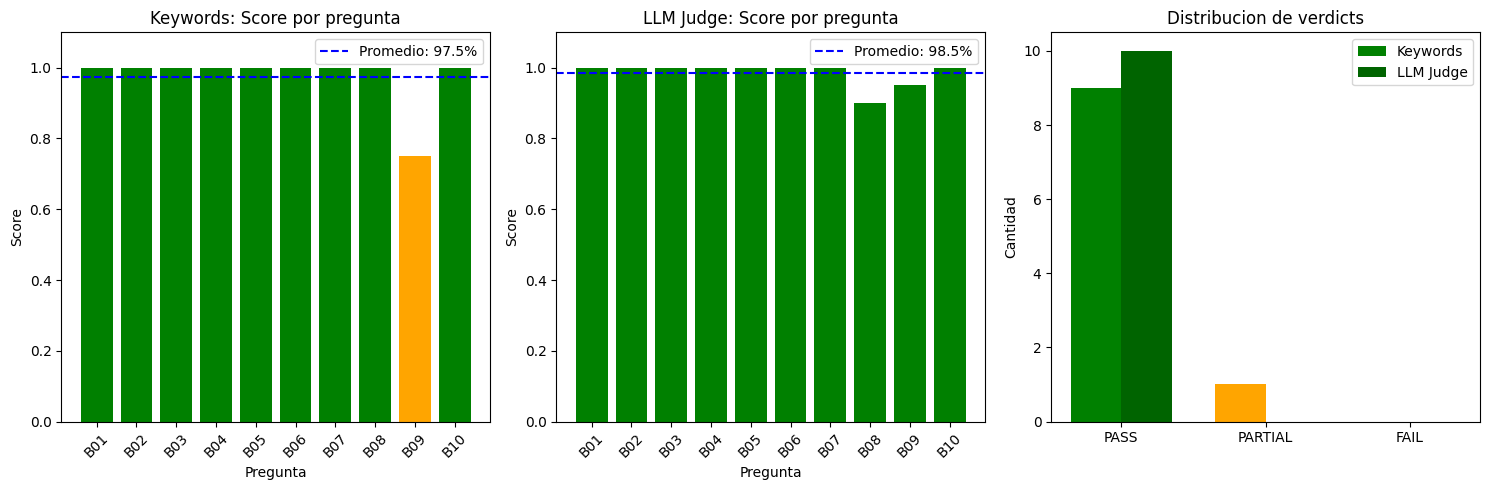


Keywords — Score promedio: 97.5%
LLM Judge — Score promedio: 98.5%


In [65]:
# ══════════════════════════════════════════════════════════════════════
# VISUALIZACION — NO MODIFICAR
# ══════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 1. Scores por pregunta — keywords
ids = [r["id"] for r in keyword_results]
kw_scores = [r["score"] for r in keyword_results]
colors_kw = ["green" if s == 1.0 else ("orange" if s > 0 else "red") for s in kw_scores]
axes[0].bar(ids, kw_scores, color=colors_kw)
axes[0].axhline(y=avg_score, color='blue', linestyle='--', label=f'Promedio: {avg_score:.1%}')
axes[0].set_ylim(0, 1.1)
axes[0].set_title("Keywords: Score por pregunta")
axes[0].set_xlabel("Pregunta")
axes[0].set_ylabel("Score")
axes[0].legend()
axes[0].tick_params(axis='x', rotation=45)

# 2. Scores por pregunta — LLM judge
llm_scores = [r["score"] for r in llm_results]
colors_llm = ["green" if s >= 0.8 else ("orange" if s >= 0.4 else "red") for s in llm_scores]
axes[1].bar(ids, llm_scores, color=colors_llm)
axes[1].axhline(y=avg_score_llm, color='blue', linestyle='--', label=f'Promedio: {avg_score_llm:.1%}')
axes[1].set_ylim(0, 1.1)
axes[1].set_title("LLM Judge: Score por pregunta")
axes[1].set_xlabel("Pregunta")
axes[1].set_ylabel("Score")
axes[1].legend()
axes[1].tick_params(axis='x', rotation=45)

# 3. Distribucion de verdicts — ambos metodos
verdicts_kw = Counter(r["status"] for r in keyword_results)
verdicts_llm = Counter(r["status"] for r in llm_results)
categories = ["PASS", "PARTIAL", "FAIL"]
x = np.arange(len(categories))
width = 0.35
bars1 = axes[2].bar(x - width/2, [verdicts_kw.get(c, 0) for c in categories], width, label='Keywords', color=['green', 'orange', 'red'])
bars2 = axes[2].bar(x + width/2, [verdicts_llm.get(c, 0) for c in categories], width, label='LLM Judge', color=['darkgreen', 'darkorange', 'darkred'])
axes[2].set_title("Distribucion de verdicts")
axes[2].set_xticks(x)
axes[2].set_xticklabels(categories)
axes[2].set_ylabel("Cantidad")
axes[2].legend()

plt.tight_layout()
plt.show()
print(f"\nKeywords — Score promedio: {avg_score:.1%}")
print(f"LLM Judge — Score promedio: {avg_score_llm:.1%}")

---

## Ejercicio 5: Analizar, refinar, re-evaluar

Mira los resultados del benchmark. Si hay preguntas con FAIL o PARTIAL:

1. **Diagnostica**: mira que tools uso el agente (o si no uso ninguna). El problema esta en las descripciones de las tools, en el system prompt, o en ambos?
2. **Refina**: volve a las celdas del Ejercicio 1 y/o 2 y modifica las descripciones o el prompt
3. **Re-evalua**: volve a correr las celdas del Ejercicio 3 y 4 para ver si mejoro

Podes repetir este ciclo cuantas veces quieras.

> Este loop de **evaluar → analizar → refinar → re-evaluar** es el flujo real
> de trabajo cuando se desarrollan agentes con LLMs.

---

## Ejercicio 6: Preguntas conceptuales

Responde en las celdas de abajo.

### 6.1 — MCP vs function calling directo
Que cambia entre registrar las tools directamente en el agente (Parte 1)
vs descubrirlas via un servidor MCP (Parte 2)? Que ventajas tiene separar
las tools del agente?

En la Parte 1, las tools estaban registradas directamente dentro del agente, lo que implica que el agente tiene conocimiento explícito de las funciones disponibles. En cambio, en la Parte 2, mediante MCP, las tools se exponen a través de un servidor y el agente las descubre. Esto introduce una separación clara entre el razonamiento del agente y el acceso a los datos.

Esta separación tiene varias ventajas. Por un lado, las tools pueden modificarse o ampliarse sin necesidad de cambiar el agente. Además, permite reutilizar las mismas tools en distintos agentes.

### 6.2 — Tool descriptions
Cual fue la descripcion mas dificil de escribir? El agente elegia mal alguna tool
hasta que mejoraste su descripcion? Que aprendiste sobre como el LLM interpreta las descripciones?

La descripción más difícil de escribir fue la de list_drugs_by_class. Al principio, el agente no lograba usar correctamente la tool, especialmente en consultas como “inhibidores de EGFR”. El problema era que el modelo generaba parámetros como “Inhibidor de EGFR”, mientras que en la base de datos las clases estaban definidas de otra forma (por ejemplo, “EGFR-TKI”), lo que hacía que no hubiera coincidencias.
Para solucionarlo, hicimos la descripción más específica, indicando no solo cuándo usar la tool, sino también cómo construir el parámetro de entrada. A partir de esto, el comportamiento del agente mejoró.
Aprendimos que las descripciones funcionan como una guía para el LLM. Si son vagas, el agente puede elegir mal la tool o usarla incorrectamente. En cambio, descripciones precisas ayudan a reducir errores.

### 6.3 — Keywords vs LLM-as-a-Judge
Hubo discrepancias entre los dos metodos de evaluacion? Cual te parece mas justo y por que?
Que ventajas y desventajas tiene cada uno?

Observamos algunas diferencias entre ambos métodos. En varios casos, keywords marcaba respuestas como parciales o incorrectas por no contener una palabra exacta (por ejemplo, “1ra linea” o “contraindicado”), aunque el contenido fuera clínicamente correcto. En cambio, LLM-as-a-Judge evaluaba esas mismas respuestas como adecuadas, ya que tiene en cuenta el significado general.
En nuestra opinión, LLM-as-a-Judge resulta más justo desde el punto de vista clínico, porque evalúa la calidad semántica de la respuesta y no solo coincidencias exactas. Sin embargo, keywords también es útil porque es objetivo.
Creemos que ambos métodos se complementan: las keywords permiten validar consistencia en el formato y uso de términos, mientras que el LLM-as-a-Judge permite evaluar la calidad real de la respuesta.

### 6.4 — Datos clinicos vs datos farmacologicos
Como se complementan el agente de Parte 1 (ensayo clinico ACME) y el de Parte 2 (medicamentos)?
Que tipo de preguntas NO puede responder este agente que si podria el de Parte 1 (y viceversa)?

Los dos agentes se complementan porque trabajan en niveles distintos: el de la Parte 1 está enfocado en la evidencia clínica (ensayos, eficacia, supervivencia, comparaciones entre tratamientos), mientras que el de la Parte 2 se centra en los medicamentos en sí (dosis, efectos adversos, mecanismo, interacciones). Básicamente, uno responde “qué tratamiento funciona mejor” y el otro “cómo usar ese tratamiento en la práctica”. Por eso, el agente farmacológico no puede responder cosas como resultados de estudios o cuál mejora más la supervivencia, mientras que el de ensayos clínicos no puede decir dosis, efectos secundarios o interacciones. 